# Этап 1 — данные и базовая метрика

Запись/загрузка чистой речи, синтез шума завода, программное смешение с контролируемым ОСШ (SNR), кратковременная оценка ОСШ и энергетический детектор речевой активности (VAD). Подробности — в `PLAN.md`, раздел «Этап 1».

In [65]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

SAMPLERATE = 16000   # Гц — частота дискретизации всего проекта
EPS = 1e-12          # маленькое число, чтобы не делить и не логарифмировать ноль

## 1. Речь

Если файл `data/samples/speech.wav` уже существует — загружается он. Иначе выполняется запись с микрофона на заданную длительность (нужна фраза с паузой внутри, чтобы VAD ниже было на чём показать разметку).

In [66]:
def record_speech(duration_s, samplerate=SAMPLERATE):
    """Записывает duration_s секунд с микрофона ПК."""
    import sounddevice as sd

    print(f"Идёт запись {duration_s:.1f} с — говорите после старта...")
    audio = sd.rec(int(duration_s * samplerate), samplerate=samplerate, channels=1, dtype="float32")
    sd.wait()
    print("Запись завершена.")
    return audio.flatten()


def load_or_record_speech(path, duration_s=6.0, samplerate=SAMPLERATE):
    """Если файл path уже существует — загружает его. Иначе записывает с микрофона
    и сохраняет, чтобы при повторном запуске запись не повторялась."""
    path = Path(path)
    if path.exists():
        speech, sr = sf.read(path, dtype="float32")
        if sr != samplerate:
            raise ValueError(f"{path}: частота дискретизации {sr} Гц, ожидалась {samplerate} Гц")
        return speech
    path.parent.mkdir(parents=True, exist_ok=True)
    speech = record_speech(duration_s, samplerate)
    sf.write(path, speech, samplerate)
    print(f"Сохранено: {path}")
    return speech


SPEECH_PATH = PROJECT_ROOT / "data" / "samples" / "speech.wav"
DURATION_S = 6.0

speech = load_or_record_speech(SPEECH_PATH, duration_s=DURATION_S, samplerate=SAMPLERATE)
print(f"Речь: {len(speech) / SAMPLERATE:.2f} с, {SAMPLERATE} Гц")
display(Audio(speech, rate=SAMPLERATE))

Речь: 6.00 с, 16000 Гц


## 2. Шум завода (синтетика)

Гул $x(t)$ — сумма 4 гармоник основной частоты `base_freq = 90` Гц с убывающими амплитудами:

$$x(t) = \sum_{k=1}^{4} a_k \sin(2\pi k f_0 t), \qquad f_0 = 90\ \text{Гц}, \quad (a_1,a_2,a_3,a_4) = (1{,}0;\ 0{,}6;\ 0{,}35;\ 0{,}2)$$

Широкополосный шум $\xi[n]$ — независимые случайные числа со стандартным нормальным распределением, по одному на каждый отсчёт:

$$\xi[n] \sim \mathcal{N}(0,1), \quad n = 0,\dots,N-1 \ \text{(независимо друг от друга)}$$

Оба слагаемых нормируются по среднеквадратичному значению $\mathrm{RMS}(x) = \sqrt{\dfrac{1}{N}\sum_{n=0}^{N-1} x[n]^2}$, складываются с весами и нормируются ещё раз:

$$w(t) = 0{,}6\cdot\frac{x(t)}{\mathrm{RMS}(x)} + 0{,}4\cdot\frac{\xi(t)}{\mathrm{RMS}(\xi)}, \qquad \text{noise}(t) = \frac{w(t)}{\mathrm{RMS}(w)}$$

В `synth_factory_noise` это считается буквально так:

```python
hum = np.zeros(n)
for k, amp in enumerate([1.0, 0.6, 0.35, 0.2], start=1):
    hum += amp * np.sin(2 * np.pi * k * base_freq * t)   # k-я гармоника: k·90 Гц

white = rng.standard_normal(n)   # N(0, 1) независимо на каждый отсчёт

noise = 0.6 * _normalize_rms(hum) + 0.4 * _normalize_rms(white)
noise = _normalize_rms(noise)    # финальная нормировка по мощности
```

где `_normalize_rms(x) = x / RMS(x)`.

Так на слух звучит вращающийся вал двигателя или вентилятора — основной тон на `base_freq` и более тихие обертоны на `2·base_freq`, `3·base_freq`, `4·base_freq` (тот же принцип, что у меандра из лекции 2 — сумма гармоник кратных частот), поверх которого лежит ровный шипящий фон. Функция возвращает все три сигнала — `noise`, `hum`, `white` — их можно послушать по отдельности плеерами ниже.

См. `synth_factory_noise`.

In [67]:
def _normalize_rms(x):
    """Приводит сигнал к единичной среднеквадратичной мощности: x / RMS(x), где
    RMS(x) = sqrt(mean(x**2)). После этого сигнал можно предсказуемо смешивать
    с другими сигналами произвольной исходной громкости — см. mix()."""
    rms = np.sqrt(np.mean(x**2) + EPS)
    return x / rms


def synth_factory_noise(duration_s, samplerate=SAMPLERATE, seed=0):
    """Синтетический шум завода = гул моторов + широкополосный шум (формула — в
    markdown-ячейке выше). Возвращает (noise, hum, white) — итоговый шум и его
    два слагаемых по отдельности, чтобы их можно было послушать/посмотреть ниже."""
    rng = np.random.default_rng(seed)
    n = int(duration_s * samplerate)
    t = np.arange(n) / samplerate

    base_freq = 90.0  # Гц — основная частота гула
    hum = np.zeros(n)
    for k, amp in enumerate([1.0, 0.6, 0.35, 0.2], start=1):
        hum += amp * np.sin(2 * np.pi * k * base_freq * t)

    white = rng.standard_normal(n)

    noise = 0.6 * _normalize_rms(hum) + 0.4 * _normalize_rms(white)
    noise = _normalize_rms(noise)
    return noise, hum, white


noise, hum, white = synth_factory_noise(duration_s=len(speech) / SAMPLERATE, samplerate=SAMPLERATE, seed=0)
print(f"Шум: {len(noise) / SAMPLERATE:.2f} с")

Шум: 6.00 с


In [68]:
from IPython.display import Audio, display

# Audio(..., normalize=True) по умолчанию сам приводит громкость к безопасному
# уровню для воспроизведения — сравнивать абсолютную громкость клипов между собой
# по этому плееру нельзя, а вот тембр (гул vs шипение vs их смесь) прекрасно слышно.

print("Гул (моторы, гармоники 90/180/270/360 Гц):")
display(Audio(hum, rate=SAMPLERATE))

print("Белый шум (широкополосная часть):")
display(Audio(white, rate=SAMPLERATE))

print("Итоговый шум завода (гул + белый шум = noise):")
display(Audio(noise, rate=SAMPLERATE))

Гул (моторы, гармоники 90/180/270/360 Гц):


Белый шум (широкополосная часть):


Итоговый шум завода (гул + белый шум = noise):


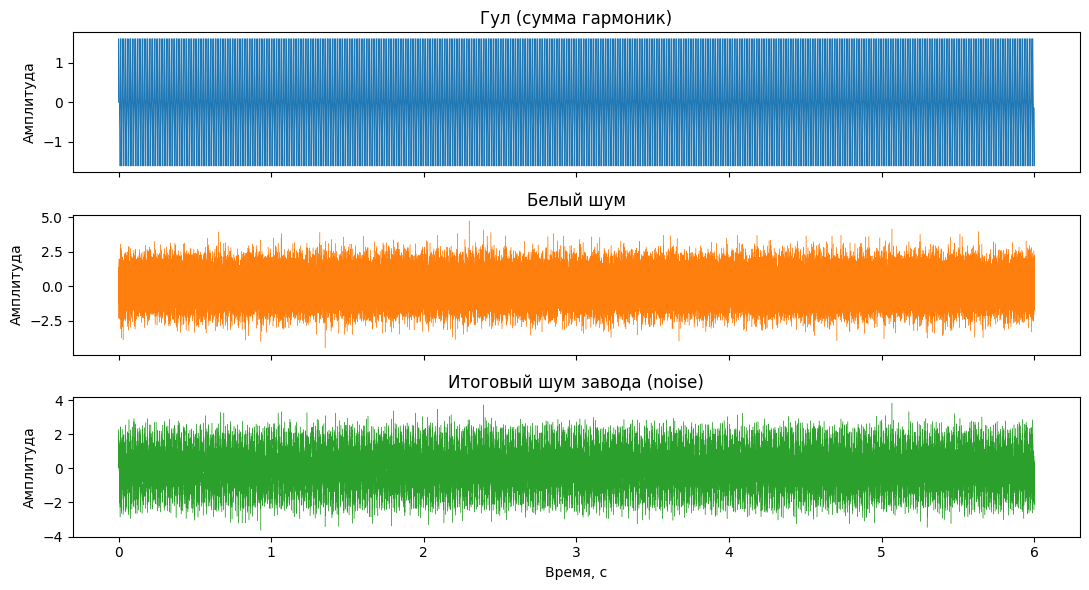

In [69]:
t_noise = np.arange(len(noise)) / SAMPLERATE

fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)

axes[0].plot(t_noise, hum, linewidth=0.6, color="tab:blue")
axes[0].set_title("Гул (сумма гармоник)")
axes[0].set_ylabel("Амплитуда")

axes[1].plot(t_noise, white, linewidth=0.3, color="tab:orange")
axes[1].set_title("Белый шум")
axes[1].set_ylabel("Амплитуда")

axes[2].plot(t_noise, noise, linewidth=0.3, color="tab:green")
axes[2].set_title("Итоговый шум завода (noise)")
axes[2].set_ylabel("Амплитуда")
axes[2].set_xlabel("Время, с")

fig.tight_layout()
plt.show()

## 3. Смешивание с контролируемым ОСШ

**Что такое ОСШ, по-простому.** ОСШ (отношение сигнал/шум, по-английски SNR) отвечает на один вопрос: во сколько раз полезный сигнал (речь) мощнее помехи (шум)? Представьте, что вы пытаетесь расслышать друга в шумном цехе: если голос друга намного громче станка — вы прекрасно всё слышите (высокое ОСШ). Если голос и шум примерно одинаковы по громкости — разобрать слова уже трудно (ОСШ около нуля). Если станок громче голоса — вы, скорее всего, ничего не разберёте (ОСШ отрицательное).

**Математически.** Мощность сигнала $x$ — среднее значение его квадрата:

$$P_x = \overline{x^2} = \frac{1}{N}\sum_{n=0}^{N-1} x[n]^2$$

ОСШ в децибелах — отношение мощности речи к мощности шума, прологарифмированное и умноженное на 10 (децибел — логарифмическая шкала для отношения мощностей):

$$\text{ОСШ (дБ)} = 10\log_{10}\frac{P_{\text{речь}}}{P_{\text{шум}}}$$

Несколько опорных значений, чтобы прочувствовать шкалу:

| ОСШ, дБ | во сколько раз речь мощнее шума | на слух |
|---|---|---|
| +20 | в 100 раз | шум почти не слышен |
| +10 | в 10 раз | шум заметен, но не мешает |
| 0 | ровно поровну | речь и шум одинаково громкие — трудно разобрать |
| −1 (наш случай) | шум чуть мощнее речи (примерно в 1,3 раза) | разобрать можно, но с трудом |
| −5 | шум мощнее речи примерно втрое | без обработки разобрать почти невозможно |
| −10 | шум мощнее речи в 10 раз | сплошной шум, речи почти не слышно |

Мы намеренно берём случай, где шум чуть мощнее речи (`SNR_DB = -1`), потому что весь смысл курса — научиться **вытаскивать** речь из шума; на чистом сигнале (высокое положительное ОСШ) подавлять было бы нечего.

**Как это сделано технически.** Готового шума с нужной мощностью нет — есть какой-то `noise` произвольной громкости $P_{\text{шум}}$, и нужно найти коэффициент $k$, на который его домножить, чтобы получить ровно целевое ОСШ. Мощность растёт с квадратом амплитуды, поэтому после умножения на $k$ мощность шума станет $k^2 P_{\text{шум}}$. Подставляем в определение ОСШ и решаем относительно $k$:

$$\text{ОСШ} = 10\log_{10}\frac{P_{\text{речь}}}{k^2 P_{\text{шум}}} \qquad\Longrightarrow\qquad k = \sqrt{\dfrac{P_{\text{речь}}}{P_{\text{шум}}\cdot 10^{\,\text{ОСШ}/10}}}$$

Именно эта формула — в коде ниже (`k = np.sqrt(...)`), после чего шум умножается на $k$ и складывается с речью.

In [70]:
def mix(speech, noise, snr_db):
    """Смешивает речь и шум так, чтобы у смеси было ровно заданное ОСШ snr_db (дБ).

    Мощность сигнала — среднее значение его квадрата: P = mean(x**2). ОСШ по
    определению — это P_речь / P_шум, выраженное в децибелах:

        ОСШ(дБ) = 10 * log10(P_речь / P_шум).

    Готового шума с нужной мощностью нет — есть некоторый noise с мощностью
    P_шум, и его нужно умножить на коэффициент k так, чтобы получить целевое ОСШ.
    Мощность растёт с КВАДРАТОМ амплитуды, поэтому после умножения на k мощность
    шума станет k**2 * P_шум. Подставляем это в определение ОСШ и решаем относительно k:

        snr_db = 10 * log10(P_речь / (k**2 * P_шум))
        10**(snr_db/10) = P_речь / (k**2 * P_шум)
        k**2 = P_речь / (P_шум * 10**(snr_db/10))
        k = sqrt(P_речь / (P_шум * 10**(snr_db/10)))

    Именно эта формула — ниже. Возвращает (смесь, речь, шум) — согласованно
    отмасштабированные, если потребовалась защита от клиппинга."""
    n = len(speech)
    reps = int(np.ceil(n / len(noise)))
    noise_full = np.tile(noise, reps)[:n]

    p_speech = np.mean(speech**2) + EPS
    p_noise = np.mean(noise_full**2) + EPS
    k = np.sqrt(p_speech / (p_noise * 10 ** (snr_db / 10)))
    noise_scaled = k * noise_full

    mixed = speech + noise_scaled
    peak = np.max(np.abs(mixed))
    if peak > 1.0:  # защита от клиппинга: если сумма вышла за [-1, 1], уменьшаем всё пропорционально
        speech = speech / peak
        noise_scaled = noise_scaled / peak
        mixed = mixed / peak
    return mixed, speech, noise_scaled


SNR_DB = -1.0

mixed, speech_used, noise_used = mix(speech, noise, snr_db=SNR_DB)

MIX_PATH = PROJECT_ROOT / "data" / "processed" / "mix.wav"
MIX_PATH.parent.mkdir(parents=True, exist_ok=True)
sf.write(MIX_PATH, mixed, SAMPLERATE)
print(f"Сохранено: {MIX_PATH}")
display(Audio(mixed, rate=SAMPLERATE))

Сохранено: d:\файлы\Documents\разное\ВУЗ\4 год\обработка сигналов\voice-noise-suppression\data\processed\mix.wav


## 4. Кратковременная оценка ОСШ

Одно число ОСШ на всю запись — грубая оценка: пока говорят, соотношение мощностей одно, а в паузе речи вообще нет, и локальное ОСШ проваливается вниз (там только шум). Поэтому `estimate_windowed_snr` считает ту же формулу ОСШ отдельно в каждом коротком окне.

**Математически.** Сигнал режется на кадры длиной $L$ отсчётов (`frame_len`, по умолчанию 32 мс) со сдвигом $H$ отсчётов (`hop_len`, 16 мс) — framing, см. `_frame_signal`. В $i$-м кадре мощность считается отдельно для речи и шума:

$$P_{\text{речь}}[i] = \frac{1}{L}\sum_{n=0}^{L-1} x_{\text{речь}}[iH+n]^2, \qquad P_{\text{шум}}[i] = \frac{1}{L}\sum_{n=0}^{L-1} x_{\text{шум}}[iH+n]^2$$

и по ним — то же определение ОСШ, что и в разделе 3, только теперь как функция номера кадра $i$ (то есть времени):

$$\text{ОСШ}[i]\ (\text{дБ}) = 10\log_{10}\frac{P_{\text{речь}}[i]}{P_{\text{шум}}[i]}$$

Так видно, как соотношение меняется во времени — вместо одного числа получаем кривую. Поскольку сдвиг $H$ (16 мс) меньше длины окна $L$ (32 мс), соседние окна перекрываются на 50% — это и есть «скользящее» (плавающее) окно: оно не перепрыгивает от блока к блоку, а плавно ползёт по сигналу, поэтому кривая ниже получается гладкой, без резких скачков между кадрами.

Поскольку речь и шум смешивались программно, обе составляющие известны по отдельности — это и заменяет физический тестовый стенд (см. `PLAN.md`, «Ограничения и допущения»).

In [71]:
def _frame_signal(signal, frame_len, hop_len):
    """Режет сигнал на короткие перекрывающиеся окна (кадры) по frame_len отсчётов
    со сдвигом hop_len между соседними кадрами ("framing") — основа всех
    кратковременных оценок ниже: вместо одного числа на весь сигнал считаем его
    отдельно в каждом маленьком окне, чтобы видеть, как сигнал меняется во времени."""
    n_frames = max(1, 1 + (len(signal) - frame_len) // hop_len)
    frames = np.zeros((n_frames, frame_len))
    for i in range(n_frames):
        start = i * hop_len
        frames[i] = signal[start : start + frame_len]
    return frames


def estimate_windowed_snr(speech, noise, samplerate=SAMPLERATE, win_ms=32.0, hop_ms=16.0):
    """Кратковременное (покадровое) ОСШ — то же определение, что и в mix()
    (10 * log10(P_речь / P_шум)), но посчитанное отдельно в каждом коротком окне
    длиной win_ms, а не для всей записи разом.

    Одно число ОСШ на всю запись слишком грубое: пока говорят — одно соотношение
    мощностей, в паузе — совсем другое (речи там нет вообще, остаётся только шум).
    Разбиение на кадры позволяет увидеть эту динамику и служит основой для VAD
    ниже. Возвращает (время центров окон, ОСШ)."""
    frame_len = int(win_ms / 1000 * samplerate)
    hop_len = int(hop_ms / 1000 * samplerate)
    speech_frames = _frame_signal(speech, frame_len, hop_len)
    noise_frames = _frame_signal(noise, frame_len, hop_len)

    p_speech = np.mean(speech_frames**2, axis=1) + EPS
    p_noise = np.mean(noise_frames**2, axis=1) + EPS
    snr_db = 10 * np.log10(p_speech / p_noise)

    centers = (np.arange(len(snr_db)) * hop_len + frame_len / 2) / samplerate
    return centers, snr_db


overall_snr_db = 10 * np.log10(np.mean(speech_used**2) / (np.mean(noise_used**2) + 1e-12))
print(f"Итоговый ОСШ смеси: {overall_snr_db:.2f} дБ (целевой: {SNR_DB:.2f} дБ)")

times, snr_curve = estimate_windowed_snr(speech_used, noise_used, samplerate=SAMPLERATE)
print(
    f"Кратковременный ОСШ: медиана {np.median(snr_curve):.1f} дБ, "
    f"мин {np.min(snr_curve):.1f} дБ (паузы), макс {np.max(snr_curve):.1f} дБ (активная речь)"
)

Итоговый ОСШ смеси: -1.00 дБ (целевой: -1.00 дБ)
Кратковременный ОСШ: медиана -26.2 дБ, мин -40.9 дБ (паузы), макс 15.9 дБ (активная речь)


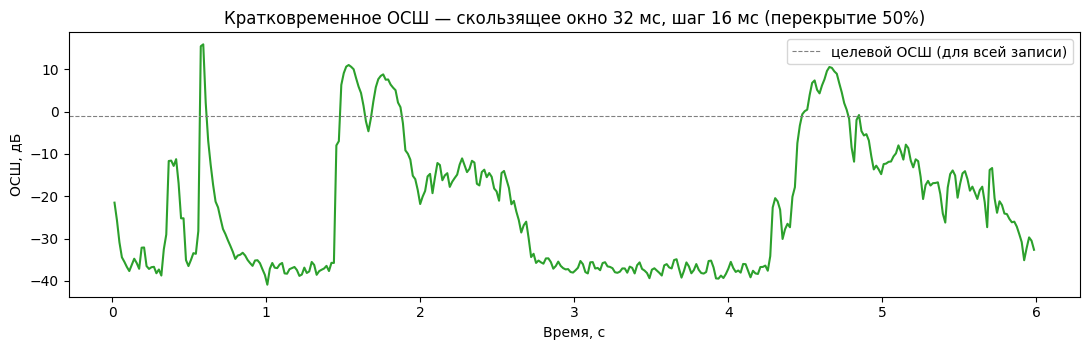

In [72]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(times, snr_curve, color="tab:green")
ax.axhline(SNR_DB, color="gray", linestyle="--", linewidth=0.8, label="целевой ОСШ (для всей записи)")
ax.set_xlabel("Время, с")
ax.set_ylabel("ОСШ, дБ")
ax.set_title("Кратковременное ОСШ — скользящее окно 32 мс, шаг 16 мс (перекрытие 50%)")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Энергетический VAD

Идея простая: пока говорят, энергия кадра заметно выше, чем в паузе, где остаётся только фоновый шум.

**Математически.** Энергия (мощность в дБ) $i$-го кадра длиной $L=$ `frame_len` (25 мс) со сдвигом $H=$ `hop_len` (10 мс):

$$E[i] = 10\log_{10}\left(\frac{1}{L}\sum_{n=0}^{L-1} x[iH+n]^2\right)$$

Порог строится в два шага: сначала «пол» — 10-й процентиль энергии по всей записи (типичный уровень тишины, если пауз в записи больше, чем речи), затем к нему добавляется запас 6 дБ:

$$\text{порог} = \operatorname{percentile}_{10}(E) + 6\ \text{дБ}$$

Кадр помечается речью, если его энергия выше порога:

$$\text{speech}[i] = \begin{cases} \text{да}, & E[i] > \text{порог} \\ \text{нет}, & E[i] \le \text{порог} \end{cases}$$

Соседние кадры с одинаковой меткой объединяются в один сегмент таймлайна.

Базовый вариант с фиксированным порогом (адаптивный порог — задача этапа 7).

In [73]:
def energy_vad(signal, samplerate=SAMPLERATE, win_ms=25.0, hop_ms=10.0, threshold_offset_db=6.0, floor_percentile=10.0):
    """Энергетический детектор речевой активности (Voice Activity Detection).

    Идея простая: пока говорят, энергия кадра заметно выше, чем в паузе, где
    остаётся только фоновый шум. Порог строится в два шага:

        1. noise_floor_db — floor_percentile-й процентиль энергии по всей записи,
           то есть уровень, ниже которого лежат самые тихие floor_percentile%
           кадров. Если пауз в записи заметно больше, чем активной речи, это
           разумная оценка "типичного уровня тишины", не требующая знать шум заранее.
        2. threshold_db = noise_floor_db + threshold_offset_db — к полу добавлен
           запас в децибелах, чтобы обычные колебания шума не принимались за речь.

    Кадр помечается как "speech", если его энергия (в дБ) выше threshold_db, и как
    "silence" иначе. Соседние кадры с одинаковой меткой объединяются в один
    сегмент. Возвращает таймлайн [{start, end, label}]."""
    frame_len = int(win_ms / 1000 * samplerate)
    hop_len = int(hop_ms / 1000 * samplerate)
    frames = _frame_signal(signal, frame_len, hop_len)
    energy_db = 10 * np.log10(np.mean(frames**2, axis=1) + EPS)

    noise_floor_db = np.percentile(energy_db, floor_percentile)
    threshold_db = noise_floor_db + threshold_offset_db
    is_speech = energy_db > threshold_db

    timeline = []
    frame_time = hop_len / samplerate
    start_idx = 0
    for i in range(1, len(is_speech) + 1):
        if i == len(is_speech) or is_speech[i] != is_speech[start_idx]:
            timeline.append(
                {
                    "start": round(start_idx * frame_time, 3),
                    "end": round(i * frame_time, 3),
                    "label": "speech" if is_speech[start_idx] else "silence",
                }
            )
            start_idx = i
    return timeline


def save_timeline(timeline, path):
    """Сохраняет таймлайн в JSON — человекочитаемо, с отступами и кириллицей как есть."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(timeline, f, ensure_ascii=False, indent=2)


timeline = energy_vad(mixed, samplerate=SAMPLERATE)

TIMELINE_PATH = PROJECT_ROOT / "data" / "processed" / "vad_timeline.json"
save_timeline(timeline, TIMELINE_PATH)
print(f"VAD-сегментов: {len(timeline)}. Сохранено: {TIMELINE_PATH}")
timeline

VAD-сегментов: 13. Сохранено: d:\файлы\Documents\разное\ВУЗ\4 год\обработка сигналов\voice-noise-suppression\data\processed\vad_timeline.json


[{'start': 0.0, 'end': 0.56, 'label': 'silence'},
 {'start': 0.56, 'end': 0.6, 'label': 'speech'},
 {'start': 0.6, 'end': 1.48, 'label': 'silence'},
 {'start': 1.48, 'end': 1.58, 'label': 'speech'},
 {'start': 1.58, 'end': 1.59, 'label': 'silence'},
 {'start': 1.59, 'end': 1.63, 'label': 'speech'},
 {'start': 1.63, 'end': 1.69, 'label': 'silence'},
 {'start': 1.69, 'end': 1.84, 'label': 'speech'},
 {'start': 1.84, 'end': 4.52, 'label': 'silence'},
 {'start': 4.52, 'end': 4.57, 'label': 'speech'},
 {'start': 4.57, 'end': 4.59, 'label': 'silence'},
 {'start': 4.59, 'end': 4.72, 'label': 'speech'},
 {'start': 4.72, 'end': 5.98, 'label': 'silence'}]

## 6. Визуализация

Сохранено: d:\файлы\Documents\разное\ВУЗ\4 год\обработка сигналов\voice-noise-suppression\results\stage01_waveform_vad.png


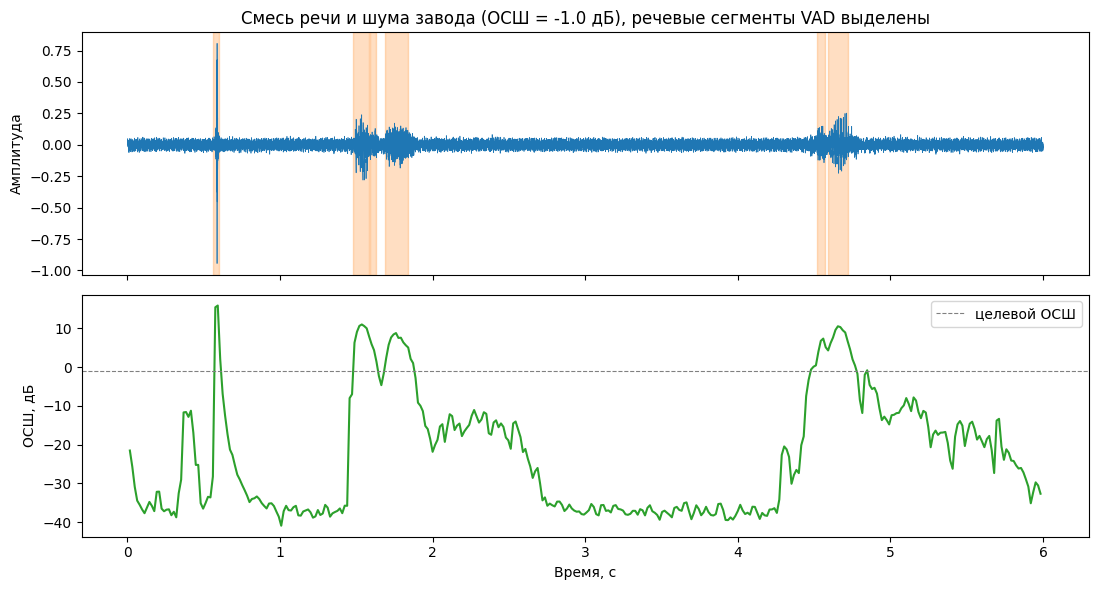

In [74]:
t_axis = np.arange(len(mixed)) / SAMPLERATE

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax1.plot(t_axis, mixed, linewidth=0.5, color="tab:blue")
for seg in timeline:
    if seg["label"] == "speech":
        ax1.axvspan(seg["start"], seg["end"], color="tab:orange", alpha=0.25)
ax1.set_ylabel("Амплитуда")
ax1.set_title(f"Смесь речи и шума завода (ОСШ = {SNR_DB:.1f} дБ), речевые сегменты VAD выделены")

ax2.plot(times, snr_curve, color="tab:green")
ax2.axhline(SNR_DB, color="gray", linestyle="--", linewidth=0.8, label="целевой ОСШ")
ax2.set_xlabel("Время, с")
ax2.set_ylabel("ОСШ, дБ")
ax2.legend()

fig.tight_layout()

RESULTS_PATH = PROJECT_ROOT / "results" / "stage01_waveform_vad.png"
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(RESULTS_PATH, dpi=150)
print(f"Сохранено: {RESULTS_PATH}")
plt.show()

In [75]:
# Проверка VAD на слух: вырезаем из смеси только те куски, которые VAD пометил
# как "speech" (по timeline из раздела 5), и склеиваем их в один короткий клип.
# Если VAD сработал верно, здесь должна быть только речь, без длинных кусков шума.
speech_only = np.concatenate(
    [mixed[int(seg["start"] * SAMPLERATE) : int(seg["end"] * SAMPLERATE)] for seg in timeline if seg["label"] == "speech"]
)

n_segments = sum(1 for seg in timeline if seg["label"] == "speech")
print(f"Вырезано {n_segments} речевых фрагмента(ов) по VAD, суммарно {len(speech_only) / SAMPLERATE:.2f} с")
display(Audio(speech_only, rate=SAMPLERATE))

Вырезано 6 речевых фрагмента(ов) по VAD, суммарно 0.51 с
